In [ ]:
# CUSTOMER PERSONALITY ANALYSIS: ML PIPELINE

# This code implements an end-to-end machine learning pipeline to predict
# customer responses to marketing campaigns using a Support Vector Machine (SVM).

# Pipeline Steps:
# 1. Data Cleaning & Preprocessing: Imputes missing income values with the median,
#    drops irrelevant columns (ID, Z_CostContact, Z_Revenue), and groups
#    categorical variables for Marital Status and Education.
# 2. Feature Engineering: Derives new features including 'Age' (calculated from
#    Year_Birth), total 'Children', and 'Total_Spending' across various product
#    categories.
# 3. Data Transformation: Applies one-hot encoding to categorical features and
#    removes outliers (Income > 200,000) and duplicate rows.
# 4. Model Training: Implements a machine learning pipeline using a Standard
#    Scaler and a Support Vector Classifier (SVC) with an RBF kernel.
# 5. Model Evaluation: Assesses model performance using accuracy scores of more than 80%,
#    a confusion matrix heatmap, and a classification report.
# 6. Random State Experiment: Includes a supplementary test demonstrating how
#    omitting the 'random_state' parameter during data splitting affects
#    model reproducibility and accuracy.
#
# Group Members:
#  Sabayo
#  Salvador
#  Balugay
#  De Leon
# ==============================================================================

In [ ]:
import pandas as pd

from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

import seaborn as sns
import matplotlib.pyplot as plt

df = pd.read_csv("marketing_campaign.csv", sep="\t")
df.head()

,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,...,NumWebVisitsMonth,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Complain,Z_CostContact,Z_Revenue,Response
0,5524,1957,Graduation,Single,58138.0,0,0,04-09-2012,58,635,...,7,0,0,0,0,0,0,3,11,1
1,2174,1954,Graduation,Single,46344.0,1,1,08-03-2014,38,11,...,5,0,0,0,0,0,0,3,11,0
2,4141,1965,Graduation,Together,71613.0,0,0,21-08-2013,26,426,...,4,0,0,0,0,0,0,3,11,0
3,6182,1984,Graduation,Together,26646.0,1,0,10-02-2014,26,11,...,6,0,0,0,0,0,0,3,11,0
4,5324,1981,PhD,Married,58293.0,1,0,19-01-2014,94,173,...,5,0,0,0,0,0,0,3,11,0


In [ ]:
# To check any missing and other values
df.info()
df.isnull().sum()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2240 entries, 0 to 2239
Data columns (total 29 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   ID                   2240 non-null   int64  
 1   Year_Birth           2240 non-null   int64  
 2   Education            2240 non-null   object 
 3   Marital_Status       2240 non-null   object 
 4   Income               2216 non-null   float64
 5   Kidhome              2240 non-null   int64  
 6   Teenhome             2240 non-null   int64  
 7   Dt_Customer          2240 non-null   object 
 8   Recency              2240 non-null   int64  
 9   MntWines             2240 non-null   int64  
 10  MntFruits            2240 non-null   int64  
 11  MntMeatProducts      2240 non-null   int64  
 12  MntFishProducts      2240 non-null   int64  
 13  MntSweetProducts     2240 non-null   int64  
 14  MntGoldProds         2240 non-null   int64  
 15  NumDealsPurchases    2240 non-null   i

,ID,Year_Birth,Income,Kidhome,Teenhome,Recency,MntWines,MntFruits,MntMeatProducts,MntFishProducts,...,NumWebVisitsMonth,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Complain,Z_CostContact,Z_Revenue,Response
count,2240.000000,2240.000000,2216.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,...,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.0,2240.0,2240.000000
mean,5592.159821,1968.805804,52247.251354,0.444196,0.506250,49.109375,303.935714,26.302232,166.950000,37.525446,...,5.316518,0.072768,0.074554,0.072768,0.064286,0.013393,0.009375,3.0,11.0,0.149107
std,3246.662198,11.984069,25173.076661,0.538398,0.544538,28.962453,336.597393,39.773434,225.715373,54.628979,...,2.426645,0.259813,0.262728,0.259813,0.245316,0.114976,0.096391,0.0,0.0,0.356274
min,0.000000,1893.000000,1730.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,3.0,11.0,0.000000
25%,2828.250000,1959.000000,35303.000000,0.000000,0.000000,24.000000,23.750000,1.000000,16.000000,3.000000,...,3.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,3.0,11.0,0.000000
50%,5458.500000,1970.000000,51381.500000,0.000000,0.000000,49.000000,173.500000,8.000000,67.000000,12.000000,...,6.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,3.0,11.0,0.000000
75%,8427.750000,1977.000000,68522.000000,1.000000,1.000000,74.000000,504.250000,33.000000,232.000000,50.000000,...,7.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,3.0,11.0,0.000000
max,11191.000000,1996.000000,666666.000000,2.000000,2.000000,99.000000,1493.000000,199.000000,1725.000000,259.000000,...,20.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,3.0,11.0,1.000000


In [ ]:
# To fill the missing values for Income Column
df["Income"] = df["Income"].fillna(df["Income"].median())
# Drops unnecessary columns (since they both have useless values)
df = df.drop(["ID", "Z_CostContact", "Z_Revenue"], axis=1)

df.isnull().sum()

,0
Year_Birth,0
Education,0
Marital_Status,0
Income,0
Kidhome,0
Teenhome,0
Dt_Customer,0
Recency,0
MntWines,0
MntFruits,0


In [ ]:
df["Marital_Status"] = df["Marital_Status"].replace(
    ["Alone", "Absurd", "YOLO"], "Single"
)

In [ ]:
df["Education"] = df["Education"].replace({
    "Basic": "Undergraduate",
    "2n Cycle": "Undergraduate",
    "Graduation": "Graduate",
    "Master": "Postgraduate",
    "PhD": "Postgraduate"
})

In [ ]:
# Separates unique values for each to easier to be read
df = pd.get_dummies(df, columns=["Education", "Marital_Status"]) # can add , drop_first=true to remove other duplicates

df = df.drop("Dt_Customer", axis=1)

df.head()

,Year_Birth,Income,Kidhome,Teenhome,Recency,MntWines,MntFruits,MntMeatProducts,MntFishProducts,MntSweetProducts,...,Complain,Response,Education_Graduate,Education_Postgraduate,Education_Undergraduate,Marital_Status_Divorced,Marital_Status_Married,Marital_Status_Single,Marital_Status_Together,Marital_Status_Widow
0,1957,58138.0,0,0,58,635,88,546,172,88,...,0,1,True,False,False,False,False,True,False,False
1,1954,46344.0,1,1,38,11,1,6,2,1,...,0,0,True,False,False,False,False,True,False,False
2,1965,71613.0,0,0,26,426,49,127,111,21,...,0,0,True,False,False,False,False,False,True,False
3,1984,26646.0,1,0,26,11,4,20,10,3,...,0,0,True,False,False,False,False,False,True,False
4,1981,58293.0,1,0,94,173,43,118,46,27,...,0,0,False,True,False,False,True,False,False,False


In [ ]:
# Converts current year value to Age (easier for the)
df["Age"] = 2026 - df["Year_Birth"]
df = df.drop("Year_Birth", axis=1)

df["Age"].describe()

,Age
count,2240.000000
mean,57.194196
std,11.984069
min,30.000000
25%,49.000000
50%,56.000000
75%,67.000000
max,133.000000


In [ ]:
# combines the kids
df["Children"] = df["Kidhome"] + df["Teenhome"]
df = df.drop(["Kidhome", "Teenhome"], axis=1)

df[["Children"]].head()

,Children
0,0
1,2
2,0
3,1
4,1


In [ ]:
# New column for all of these below
df["Total_Spending"] = (
    df["MntWines"] +
    df["MntFruits"] +
    df["MntMeatProducts"] +
    df["MntFishProducts"] +
    df["MntSweetProducts"] +
    df["MntGoldProds"]
)

df[["Total_Spending"]].head()

,Total_Spending
0,1617
1,27
2,776
3,53
4,422


In [ ]:
df["Income"].describe()

,Income
count,2240.000000
mean,52237.975446
std,25037.955891
min,1730.000000
25%,35538.750000
50%,51381.500000
75%,68289.750000
max,666666.000000


In [ ]:
# To remove unrealistic income or values
df = df[df["Income"] < 200000]
df["Income"].describe()

,Income
count,2239.000000
mean,51963.554712
std,21410.672116
min,1730.000000
25%,35533.500000
50%,51381.500000
75%,68277.500000
max,162397.000000


In [ ]:
df.head()
df.shape
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 2239 entries, 0 to 2239
Data columns (total 31 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Income                   2239 non-null   float64
 1   Recency                  2239 non-null   int64  
 2   MntWines                 2239 non-null   int64  
 3   MntFruits                2239 non-null   int64  
 4   MntMeatProducts          2239 non-null   int64  
 5   MntFishProducts          2239 non-null   int64  
 6   MntSweetProducts         2239 non-null   int64  
 7   MntGoldProds             2239 non-null   int64  
 8   NumDealsPurchases        2239 non-null   int64  
 9   NumWebPurchases          2239 non-null   int64  
 10  NumCatalogPurchases      2239 non-null   int64  
 11  NumStorePurchases        2239 non-null   int64  
 12  NumWebVisitsMonth        2239 non-null   int64  
 13  AcceptedCmp3             2239 non-null   int64  
 14  AcceptedCmp4             2239

In [ ]:
df.duplicated().sum()
df = df.drop_duplicates()

# Run again to check
df.duplicated().sum()

np.int64(0)

In [ ]:
df["Response"].value_counts()

,count
Response,
0,1743
1,312


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 2055 entries, 0 to 2239
Data columns (total 31 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Income                   2055 non-null   float64
 1   Recency                  2055 non-null   int64  
 2   MntWines                 2055 non-null   int64  
 3   MntFruits                2055 non-null   int64  
 4   MntMeatProducts          2055 non-null   int64  
 5   MntFishProducts          2055 non-null   int64  
 6   MntSweetProducts         2055 non-null   int64  
 7   MntGoldProds             2055 non-null   int64  
 8   NumDealsPurchases        2055 non-null   int64  
 9   NumWebPurchases          2055 non-null   int64  
 10  NumCatalogPurchases      2055 non-null   int64  
 11  NumStorePurchases        2055 non-null   int64  
 12  NumWebVisitsMonth        2055 non-null   int64  
 13  AcceptedCmp3             2055 non-null   int64  
 14  AcceptedCmp4             2055

In [ ]:
cols = [
    # Customer info
    "Age", "Income", "Children",

    # Education
    "Education_Graduate", "Education_Postgraduate", "Education_Undergraduate",

    # Marital Status
    "Marital_Status_Single", "Marital_Status_Together",
    "Marital_Status_Married", "Marital_Status_Divorced",
    "Marital_Status_Widow",

    # Behavior
    "Recency", "NumWebVisitsMonth",

    # Purchases in different platform/locations
    "NumDealsPurchases", "NumWebPurchases",
    "NumCatalogPurchases", "NumStorePurchases",

    # Spending
    "MntWines", "MntFruits", "MntMeatProducts",
    "MntFishProducts", "MntSweetProducts", "MntGoldProds",
    "Total_Spending",

    # Campaign history
    "AcceptedCmp1", "AcceptedCmp2", "AcceptedCmp3",
    "AcceptedCmp4", "AcceptedCmp5",

    # Other
    "Complain",

    # Target
    "Response"
]

df = df[cols]

In [ ]:
df.to_csv("cleaned_marketing_campaign.csv", index=False)

In [ ]:
# Load your cleaned dataset
import pandas as pd
import numpy as np

df = pd.read_csv('cleaned_marketing_campaign.csv')
print("Dataset shape:", df.shape)
print("\nTarget distribution:")
print(df['Response'].value_counts())

Dataset shape: (2055, 31)

Target distribution:
Response
0    1743
1     312
Name: count, dtype: int64


In [ ]:
y = df["Response"]
X = df.drop("Response", axis=1)

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (2055, 30)
y shape: (2055,)


In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

In [ ]:
model = Pipeline([
    ("scaler", StandardScaler()),
    ("model", SVC(
        kernel="rbf",
        C=30,
        gamma=0.001,
        random_state=42
    ))
])

model.fit(X_train, y_train)

y_pred = model.predict(X_test)

print(f"Final Accuracy Score: {accuracy_score(y_test, y_pred) * 100:.2f}%")

Final Accuracy Score: 89.29%


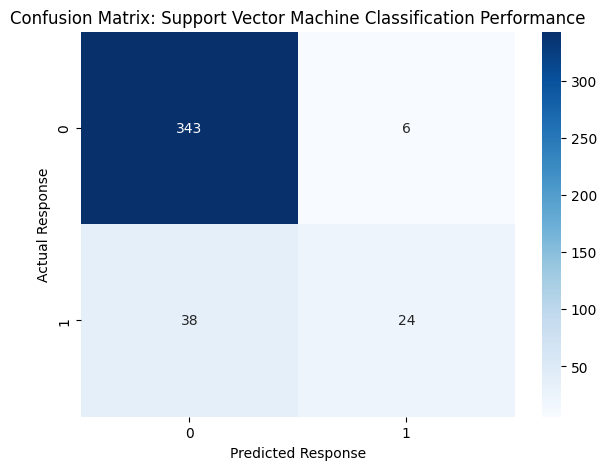

In [ ]:
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(7,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')

plt.title('Confusion Matrix: Support Vector Machine Classification Performance')
plt.ylabel('Actual Response')
plt.xlabel('Predicted Response')

plt.show()

In [ ]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.90      0.98      0.94       349
           1       0.80      0.39      0.52        62

    accuracy                           0.89       411
   macro avg       0.85      0.68      0.73       411
weighted avg       0.89      0.89      0.88       411



In [ ]:
# For Q2: Running the exact same SVM algorithm twice WITHOUT the random_state parameter.

print("Run without the random_state parameter in the train_test_split")

#first run
X_train1, X_test1, y_train1, y_test1 = train_test_split(X, y, test_size=0.20, stratify=y)

model1 = Pipeline([
    ("scaler", StandardScaler()),
    ("model", SVC(
        kernel="rbf",
        C=30,
        gamma=0.001))
])
model1.fit(X_train1, y_train1)

acc1 = accuracy_score(y_test1, model1.predict(X_test1))
print(f"Run 1 Accuracy Score: {acc1 * 100:.2f}%")


#Second run
X_train2, X_test2, y_train2, y_test2 = train_test_split(X, y, test_size=0.20, stratify=y)

model2 = Pipeline([
    ("scaler", StandardScaler()),
    ("model", SVC(
        kernel="rbf",
        C=30,
        gamma=0.001))
])
model2.fit(X_train2, y_train2)

acc2 = accuracy_score(y_test2, model2.predict(X_test2))
print(f"Run 2 Accuracy Score: {acc2 * 100:.2f}%")

print("\nThe exact same code produced two different accuracy scores because the lack of random_state caused the data to shuffle differently each time.")

Run without the random_state parameter in the train_test_split
Run 1 Accuracy Score: 87.35%
Run 2 Accuracy Score: 88.81%

The exact same code produced two different accuracy scores because the lack of random_state caused the data to shuffle differently each time.
